<a href="https://colab.research.google.com/github/sandrarajp/E-commerce-data-science-business/blob/main/Eccomerce_Data_Science_%26_BS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mount Google Drive:**

In [28]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

# List the contents of your Google Drive
# You can modify the path to navigate to specific folders
drive_path = '/content/drive/MyDrive/Bases de Datos 2026'

if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"'{drive_path}' not found. Make sure your Google Drive is mounted correctly and the path is correct.")

'/content/drive/MyDrive/Bases de Datos 2026' not found. Make sure your Google Drive is mounted correctly and the path is correct.


**Import Libraries:**

In [31]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset:**

In [32]:
csv_file_path = os.path.join(drive_path, 'online_retail_II.csv')
df = pd.read_csv("/content/drive/MyDrive/Online Retail.csv")
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


**Clean Column Names:**

In [33]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)

df.columns


Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

**Data Cleaning:**

In [34]:
# Convert invoice date to datetime
df['invoicedate'] = pd.to_datetime(pd.to_datetime(df['invoicedate'], format='%m/%d/%y %H:%M', errors='coerce'))

# Detect correct price column safely
price_col = 'price' if 'price' in df.columns else 'unitprice'

# Drop rows missing key fields
df = df.dropna(subset=['invoicedate', 'quantity', price_col, 'country'])

# Define return logic using the CORRECT invoice column
df['is_return'] = (
    df['invoiceno'].astype(str).str.startswith('C') |
    (df['quantity'] < 0)
)
# Absolute quantity for consistent aggregation
df['abs_quantity'] = df['quantity'].abs()


**Product** **return** **risk** **key** **questions**:

* Which products have the highest return rates as a share of units sold?

* Do high-return products share characteristics such as price range or category?

* Does a Pareto pattern hold — do a small number of products account for most returns?



**Customer** **return** **risk** **key** **questions**:

* What share of customers accounts for the majority of return volume?

* Do high-return customers show distinct purchasing behavior, such as higher order frequency or larger basket sizes?

* Is there a correlation between purchase frequency and return rate?



**Geographic** and **temporal** **key** **questions**:

* Are return rates significantly higher in specific countries?

* Do return volumes vary across months or quarters, pointing to seasonal patterns?



**Feature Engineering:**

In [35]:
# Revenue (can be negative for returns)
df['revenue'] = df['quantity'] * df['unitprice']

# Month & year for time analysis
df['year_month'] = df['invoicedate'].dt.to_period('M')

# Clean dataset (optional but recommended)
df_clean = df[df['quantity'] > 0]  # sales only
df_returns = df[df['is_return']]   # returns only

 **Geographical analysis**: Are return rates higher in specific countries?

In [36]:
country_summary = df.groupby('country').agg(
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum')
)

country_summary['return_rate'] = country_summary['return_qty'] / country_summary['total_qty']
country_summary = country_summary.sort_values(by='return_rate', ascending=False)

display(country_summary.head(10))

,total_qty,return_qty,return_rate
country,,,
USA,3882,112,0.028851
Malta,996,15,0.015060
Saudi Arabia,85,1,0.011765
Czech Republic,750,5,0.006667
Italy,8225,45,0.005471
Germany,121078,453,0.003741
Poland,3715,11,0.002961
Bahrain,368,1,0.002717
European Community,501,1,0.001996


USA → 2.8%

Malta → 1.5%

Germany → 0.37%

**Interpretation**:

•	High return rate countries:

o	USA, Malta, Saudi Arabia (but low volume)


“Some countries show higher return rates, but many of these have low transaction volumes, suggesting that small sample sizes may distort return percentages.”



**Visual:**

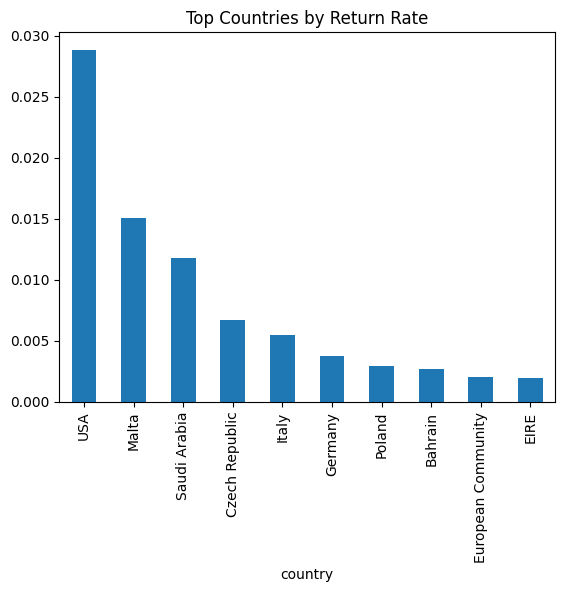

In [37]:
country_summary.head(10)['return_rate'].plot(kind='bar')
plt.title("Top Countries by Return Rate")
plt.show()

**Interpretation**: Major markets like Germany show relatively stable and low return rates.

**Time / Seasonality Analysis:** Do returns vary across months?

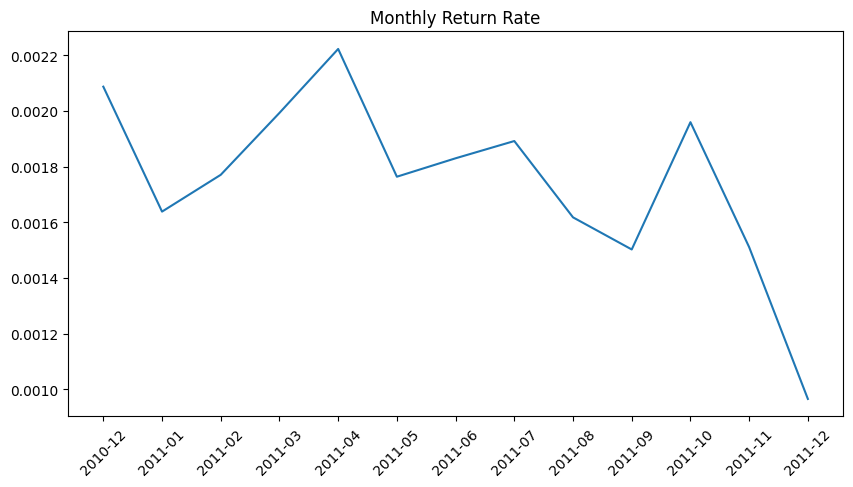

In [38]:
monthly = df.groupby('year_month').agg(
    total=('abs_quantity', 'sum'),
    returns=('is_return', 'sum')
)

monthly['return_rate'] = monthly['returns'] / monthly['total']
monthly = monthly.reset_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly['year_month'].astype(str), monthly['return_rate'])
plt.xticks(rotation=45)
plt.title("Monthly Return Rate")
plt.show()

**Interpretation**: Return rates fluctuate over time, with noticeable changes across months, indicating potential seasonal effects, especially during high-sales periods.

“Return rates tend to increase after peak sales periods, consistent with post-holiday return behavior.”


**Product Analysis:** Which products have highest return rates?

In [44]:
# Step 1: Create summary
product_summary = df.groupby('stockcode').agg(
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum'),
    avg_price=('unitprice', 'mean')
)

# Step 2: Calculate return rate
product_summary['return_rate'] = product_summary['return_qty'] / product_summary['total_qty']

# Step 3: Remove non-product codes
exclude_codes = ['S', 'D', 'POST', 'M']
product_summary = product_summary[~product_summary.index.isin(exclude_codes)]

# Step 4: Remove low-volume noise
product_summary = product_summary[product_summary['total_qty'] > 50]

# Step 5: Sort
product_summary = product_summary.sort_values(by='return_rate', ascending=False)

# Step 6: Display
display(product_summary.head(10))

,total_qty,return_qty,avg_price,return_rate
stockcode,,,,
22655,81,9,147.457447,0.111111
23462,132,13,20.143390,0.098485
21275,56,4,16.766471,0.071429
23458,56,4,14.950000,0.071429
23487,89,6,10.315600,0.067416
84631,76,5,7.765667,0.065789
22826,62,4,115.388889,0.064516
22168,183,11,8.108427,0.060109
22797,204,12,18.361262,0.058824


**Intrepretation:**
* Higher-priced items tend to show relatively higher return rates compared to lower-priced products, suggesting that expensive products may involve greater customer expectations or dissatisfaction risk.
* Some products combine both high sales volume and relatively high return rates, making them particularly impactful on overall return costs.

* Returns are not randomly distributed across products. Instead, certain products consistently show higher return rates, indicating product-specific return risks.


**Pareto Analysis:**

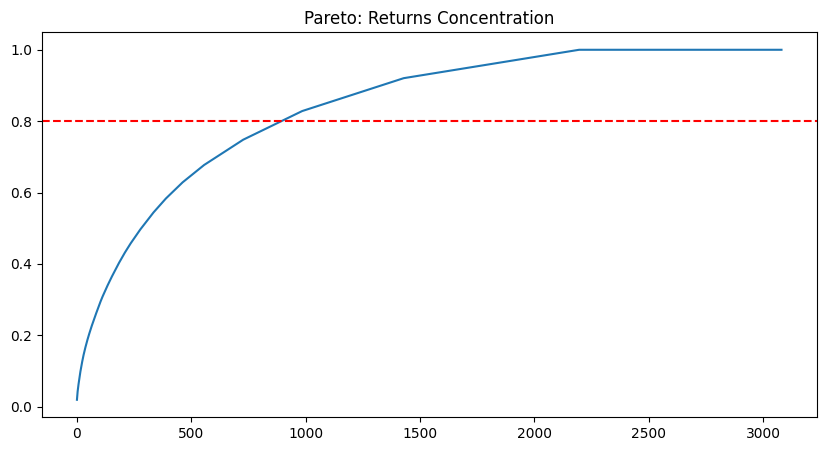

In [40]:
# Sort by return quantity
pareto = product_summary.sort_values(by='return_qty', ascending=False)

# Cumulative %
pareto['cum_pct'] = pareto['return_qty'].cumsum() / pareto['return_qty'].sum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(pareto['cum_pct'].values)
plt.axhline(0.8, color='red', linestyle='--')
plt.title("Pareto: Returns Concentration")
plt.show()


**Interpretation**: The Pareto distribution shows that a small percentage of products accounts for the majority of returns, confirming that return risk is highly concentrated.”

* The analysis reveals a moderately concentrated Pareto pattern, where a subset of products contributes disproportionately to returns, though not strictly following an 80/20 rule.”


**Customer Analysis:** Who are the high-return customers?

In [41]:
customer_summary = df.groupby('customerid').agg(
    total_orders=('invoiceno', 'nunique'),
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum')
)

customer_summary['return_rate'] = customer_summary['return_qty'] / customer_summary['total_qty']

customer_summary = customer_summary.sort_values(by='return_qty', ascending=False)

customer_summary.head(10)


,total_orders,total_qty,return_qty,return_rate
customerid,,,,
14911.0,248,83850,226,0.002695
17841.0,169,23277,136,0.005843
17511.0,46,66086,113,0.001710
15311.0,118,38668,112,0.002896
12607.0,2,2456,101,0.041124
14410.0,15,853,93,0.109027
13798.0,63,24382,90,0.003691
14606.0,128,6470,82,0.012674
13113.0,40,3506,79,0.022533


Customer 14911 → high volume, low return rate
Customer 14410 → high return rate (10%)

**Interpretation**:

“Most high-volume customers exhibit relatively low return rates, suggesting stable purchasing behavior.”

“However, a small subset of customers has disproportionately high return rates, indicating potential high-risk customer segments.”


**Correlation Analysis:**

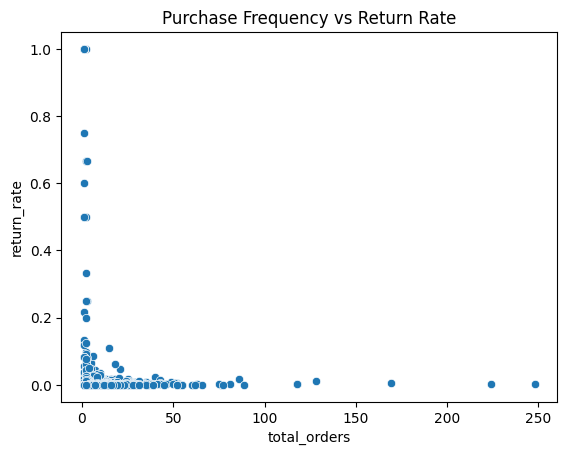

In [42]:
sns.scatterplot(
    data=customer_summary,
    x='total_orders',
    y='return_rate'
)
plt.title("Purchase Frequency vs Return Rate")
plt.show()


**Interpretation**:
There is no strong linear relationship between purchase frequency and return rate, although some high-frequency customers show elevated return behavior.”

**Behavior Analysis (Basket Size) :**

<Axes: xlabel='is_return', ylabel='basket_size'>

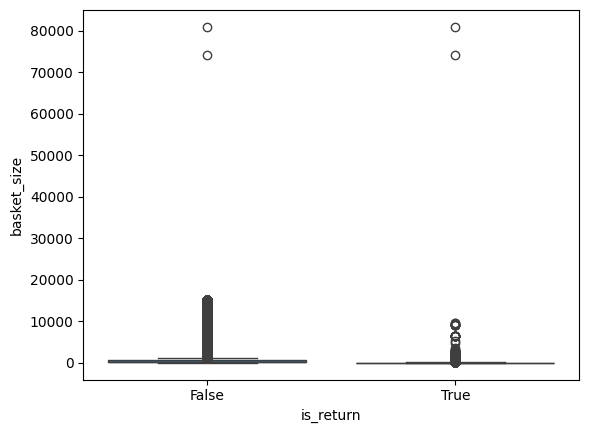

In [43]:
basket_size = df.groupby('invoiceno')['abs_quantity'].sum()

basket_df = df.merge(basket_size.rename('basket_size'), on='invoiceno')

sns.boxplot(x='is_return', y='basket_size', data=basket_df)


 **Interpretation**: Orders associated with returns tend to have larger basket sizes, suggesting that the probability of returns increases with order complexity

**COUNTRY + PRODUCT LINK**

In [45]:
#  Analyze top products returned in USA
usa_df = df[df['country'] == 'USA']

usa_products = usa_df.groupby('stockcode').agg(
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum')
)

usa_products['return_rate'] = usa_products['return_qty'] / usa_products['total_qty']

usa_products = usa_products.sort_values(by='return_rate', ascending=False)

usa_products.head(10)

,total_qty,return_qty,return_rate
stockcode,,,
22848,2,1,0.500000
21524,4,1,0.250000
20750,4,1,0.250000
48185,4,1,0.250000
22139,6,1,0.166667
22138,6,1,0.166667
47590A,6,1,0.166667
22720,7,1,0.142857
22199,8,1,0.125000


**Intrepretation:**

The analysis reveals that high return rates in the USA are driven by specific products rather than general customer behavior, indicating that product-level issues such as quality or expectation mismatch may be responsible for returns in this region.

**CUSTOMER + PRODUCT LINK**

In [46]:
# High-return customers
high_return_customers = customer_summary.sort_values(
    by='return_rate', ascending=False
).head(10)

# Filter data
high_cust_ids = high_return_customers.index

df_high = df[df['customerid'].isin(high_cust_ids)]

# Products they return
high_cust_products = df_high.groupby('stockcode').agg(
    return_qty=('is_return', 'sum')
).sort_values(by='return_qty', ascending=False)

high_cust_products.head(10)


,return_qty
stockcode,
M,5
21259,1
22423,1
22504,1
22505,1
22279,1
22697,1
22699,1
22891,1


**Intrepretation:**

 High-return customers tend to return specific types of products repeatedly, suggesting that return behavior may be linked to product categories rather than random actions.

**TIME + PRODUCT**

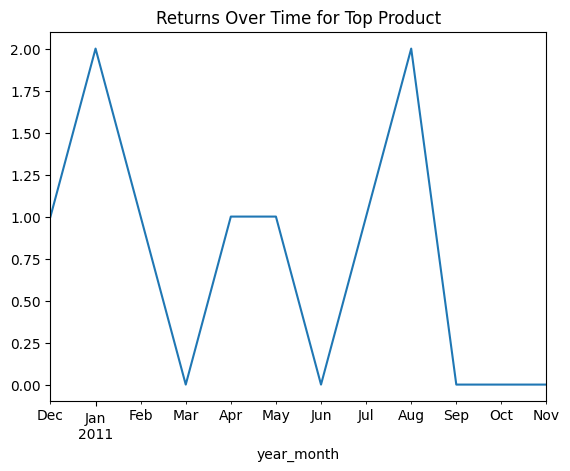

In [47]:
# Monthly returns for top product
top_product = '22655'

df[df['stockcode'] == top_product].groupby('year_month')['is_return'].sum().plot()
plt.title("Returns Over Time for Top Product")
plt.show()

**Intrepretation:**

 Certain products show spikes in returns during specific months, indicating seasonal factors or promotional impacts.

**Cross-Analysis Insights:**

To further explore return patterns, additional analysis was conducted to connect geographic, product, and customer dimensions.
* The results show that high return rates in specific countries are driven primarily by particular products rather than general market behavior.
* Similarly, high-return customers tend to return specific items repeatedly.
* These findings suggest that return behavior is not random, but arises from interactions between product characteristics, customer behavior, and regional factors.

**INSIGHTS SUMMARY**

---


 **Product**

* Return risk is highly concentrated in a small set of products
* Some items consistently generate higher return rates

**Customer**

* Small group of customers drives a large share of returns
* High purchase frequency does not always mean high returns

**Geographic**

* Return rates vary across countries
* Small markets may distort results

**Time**

* Returns show seasonal patterns
* Higher after peak sales periods

**Behavior**

Larger orders increase return likelihood

**BUSINESS RECOMMENDATIONS**


---


📦 **Product Level**

* Identify and prioritize high-return products
* Reassess pricing for frequently returned items

*Improve:*

* Product descriptions
* Images
* Quality assurance





👤 **Customer Level**

* Identify high-return customers
* Use personalized communication to reduce returns

 *Implement:*

* Monitoring systems
* Return policies (limits if needed)






🌍 **Geographic Strategy**

* Investigate high-return regions

*Improve:*

* Shipping reliability
* Packaging quality
* Delivery accuracy



📅 **Operational Strategy**

* Prepare for seasonal return spikes

*Optimize:*

* Staffing
* Inventory management



**Conclusion:**

This analysis demonstrates that product returns are driven by identifiable and actionable factors rather than random behavior.
* Return activity is concentrated among specific products, influenced by customer behavior, and varies across geographic regions and time periods.
* By leveraging these insights, businesses can implement targeted strategies to reduce return rates, improve customer satisfaction, and enhance operational efficiency.
 * The dataset includes non-product transaction codes (e.g., discounts and postage), which required cleaning to ensure accurate product-level insights.”

*"Return behavior is not random but driven by identifiable factors at the product, customer, and operational levels.”*

